In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "utils.py").exists():
    PROJECT_DIR = Path(r"D:\Github\Personal-Project\ndhu\房地產")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from utils import (
    add_centered_square,
    add_relative_time,
    NUMERIC_COLUMNS,
    describe_columns,
    filter_rows,
    ols,
    plot_residual_diagnostics,
    predict_price,
    prepare_model_rows,
    print_model_comparison,
    print_residual_diagnostics,
    print_summary,
    print_vif_table,
    read_xlsx_records,
    robust_ols_result,
    variance_inflation_factors,
)

DATA_PATH = PROJECT_DIR / "591_實價登錄整理.xlsx"
print(DATA_PATH.exists(), DATA_PATH)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
True d:\Github\Personal-Project\ndhu\房地產\591_實價登錄整理.xlsx


## 1. 資料來源與研究目的

資料來源為整理後的實價登錄 Excel，樣本鎖定同一社區或高度可比較的交易。應變數採 `ln(成交總價_含車位_萬元)`，主要自變數包含建坪、樓層、屋齡、屋齡平方、是否有車位與中高樓層虛擬變數。

使用 log-linear 模型的原因是係數可以近似解讀為百分比影響，也能降低總價尺度差異對模型的影響。

In [2]:
records = read_xlsx_records(DATA_PATH)
print(f"Loaded {len(records)} rows")
print("Columns:", list(records[0]))
for row in records[:3]:
    print(row)

Loaded 46 rows
Columns: ['Case_ID', '成交年月', '成交日期', '成交總價_含車位_萬元', '建坪_含車位', '樓層', '總樓層', '屋齡', '屋齡平方', '有車位虛擬變數', '中高樓層虛擬變數', '地址']
{'Case_ID': '7256601', '成交年月': '115-02', '成交日期': '2026-02-01', '成交總價_含車位_萬元': '1880', '建坪_含車位': '67.400000000000006', '樓層': '5', '總樓層': '9', '屋齡': '9.31', '屋齡平方': '86.676100000000005', '有車位虛擬變數': '1', '中高樓層虛擬變數': '1', '地址': '中美路111號 | 5樓之1'}
{'Case_ID': '7121628', '成交年月': '114-10', '成交日期': '2025-10-13', '成交總價_含車位_萬元': '670', '建坪_含車位': '25.5', '樓層': '1', '總樓層': '9', '屋齡': '9', '屋齡平方': '81', '有車位虛擬變數': '1', '中高樓層虛擬變數': '0', '地址': '中美路111號之6 | 1,2樓'}
{'Case_ID': '7091875', '成交年月': '114-06', '成交日期': '2025-06-08', '成交總價_含車位_萬元': '1870', '建坪_含車位': '65.400000000000006', '樓層': '4', '總樓層': '9', '屋齡': '8.66', '屋齡平方': '74.995599999999996', '有車位虛擬變數': '1', '中高樓層虛擬變數': '1', '地址': '中美路111號 | 4樓之3'}


## 2. 變數清理與模型設定

同一棟建物的 `總樓層` 與三個距離欄位沒有變異，無法在回歸中估計效果。`成交年分數` 與 `屋齡` 在單一建物樣本中高度重疊，因此主模型保留屋齡；之後另外提供一個「時間趨勢」的敏感度模型作交叉檢查。

In [3]:
excluded_case_ids = {"7121628"}  # 改成 set() 就是不排除任何樣本；可放多個 Case_ID

model_rows = prepare_model_rows(records)
model_rows, first_transaction_time = add_relative_time(
    model_rows,
    time_col="成交年分數",
    relative_col="成交年分數_相對起點",
)
regression_rows, excluded_rows = filter_rows(model_rows, excluded_case_ids)

print(f"最早成交年分數: {first_transaction_time:.4f}")

print(f"原始樣本數: {len(model_rows)}")
print(f"排除樣本數: {len(excluded_rows)}")
print(f"回歸樣本數: {len(regression_rows)}")
for row in excluded_rows:
    print("排除:", {key: row.get(key) for key in ["Case_ID", "成交日期", "成交總價_含車位_萬元", "建坪_含車位", "樓層", "屋齡", "地址"]})

available_numeric_columns = [
    col for col in NUMERIC_COLUMNS
    if any(row.get(col) is not None for row in regression_rows)
]

for item in describe_columns(regression_rows, available_numeric_columns + ["成交年分數", "成交年分數_相對起點"]):
    print(
        f"{item['欄位']}: "
        f"min={item['min']:,.4g}, "
        f"max={item['max']:,.4g}, "
        f"unique={item['unique']}"
    )

最早成交年分數: 2016.9304
原始樣本數: 46
排除樣本數: 1
回歸樣本數: 45
排除: {'Case_ID': '7121628', '成交日期': '2025-10-13', '成交總價_含車位_萬元': 670.0, '建坪_含車位': 25.5, '樓層': 1.0, '屋齡': 9.0, '地址': '中美路111號之6 | 1,2樓'}
成交總價_含車位_萬元: min=1,300, max=2,838, unique=32
建坪_含車位: min=60.8, max=102.2, unique=20
樓層: min=1, max=9, unique=8
總樓層: min=9, max=9, unique=1
屋齡: min=0.15, max=9.31, unique=22
屋齡平方: min=0.0225, max=86.68, unique=22
有車位虛擬變數: min=0, max=1, unique=2
中高樓層虛擬變數: min=0, max=1, unique=2
成交年分數: min=2,017, max=2,026, unique=22
成交年分數_相對起點: min=0, max=9.153, unique=22


## 3. 候選非線性模型：log-linear hedonic model

候選非線性模型：`ln(總價) = 建坪 + 樓層 + 屋齡 + 屋齡平方 + 車位 + 中高樓層`。

此模型保留屋齡平方，用來捕捉屋齡對價格的非線性影響。不過原始屋齡與屋齡平方通常會高度相關，因此後續會用 VIF 檢查共線性。

### 3.1 候選模型

VIF 判讀上，通常 VIF 大於 5 代表需要注意，大於 10 代表共線性偏嚴重。殘差診斷則觀察 Jarque-Bera 常態性檢定、Breusch-Pagan 異質變異檢定，以及 Cook's distance 高影響力樣本。

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     65.31
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           8.35e-19
Time:                        18:47:05   Log-Likelihood:                 56.516
No. Observations:                  46   AIC:                            -99.03
Df Residuals:                      39   BIC:                            -86.23
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1463      0.096     64.325      0.0

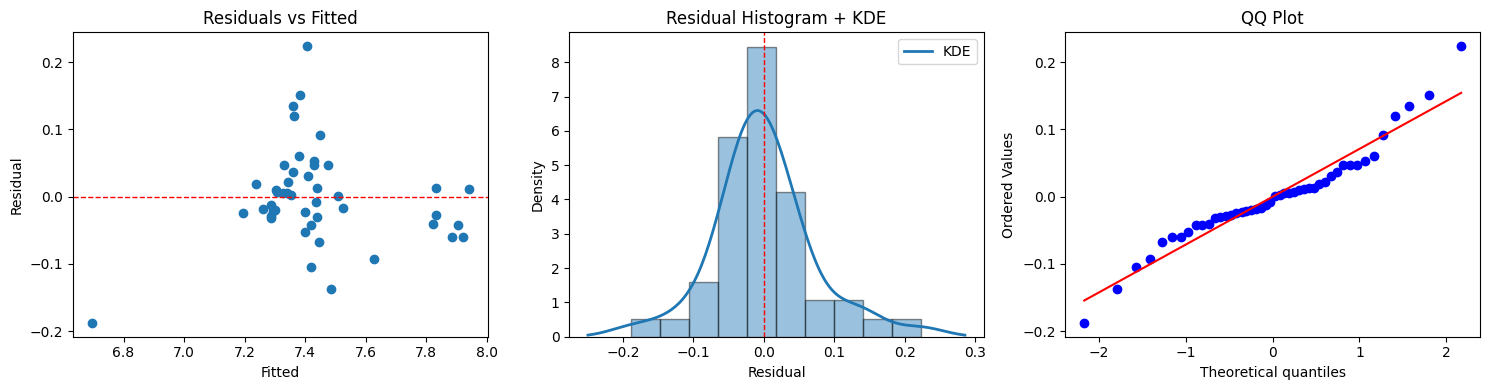

In [4]:
v1_features = [
    "建坪_含車位",
    "樓層",
    "屋齡",
    "屋齡平方",
    "有車位虛擬變數",
    "中高樓層虛擬變數",
]

v1_result = ols(
    model_rows,
    "ln_price",
    v1_features,
    exclude_case_ids=set()
)
print_summary(v1_result)

print("\n模型 VIF")
print_vif_table(variance_inflation_factors(v1_result["rows"], v1_features))

print("\n模型殘差診斷")
print_residual_diagnostics(
    v1_result["rows"],
    v1_result,
    v1_features,
    id_cols=["Case_ID", "成交日期", "成交總價_含車位_萬元", "建坪_含車位", "樓層", "屋齡"],
)

plot_residual_diagnostics(v1_result);

### 3.2 候選模型：移除屋齡平方

雖然過去住宅特徵價格模型（hedonic pricing model）文獻指出，屋齡對房價的影響可能並非單純線性。Malpezzi（2002）整理住宅特徵價格模型時，指出房價可由住宅本身與區位等屬性共同解釋；Goodman and Thibodeau（1995）進一步討論屋齡與住宅市場價值之關係，並指出屋齡可能影響房價模型中的誤差結構；Clapp（1998）也從住宅屋齡效果的角度說明，屋齡變數可能同時反映建物折舊、需求變化與市場預期。因此，在理論上，加入屋齡平方項可用來捕捉屋齡對價格的非線性影響。

但因為以下理由，最終主模型移除屋齡平方：

第一，排除高影響力樣本後僅有 45 筆實價登錄資料，樣本數偏小，若再加入屋齡平方項，容易使模型估計不穩定。
第二，樣本主要來自同一棟大樓，同一建案的屋齡變化本身與成交時間高度重疊，因此屋齡效果可能混入市場時間趨勢，較難單獨解釋為純粹折舊效果
第三，屋齡與屋齡平方存在結構性共線性問題，候選非線性模型最高 VIF 仍高於 17；雖然可透過屋齡中心化降低共線性，但屋齡中心化後的平方項仍未達傳統 5% 顯著水準，顯示本樣本缺乏足夠證據支持屋齡具有明顯非線性效果。

所以，這裡並非否定屋齡平方項的理論意義，而是基於本研究樣本數偏小、同棟大樓資料可能混入市場趨勢、以及平方項估計不穩且不顯著等考量，最終採用較簡化且較穩定的模型設定，移除屋齡平方項，僅保留屋齡線性項作為控制變數。

然後從主模型的cooks distance發現有一筆資料`Case_ID = 7121628`很奇怪，去看源頭發現是特殊交易，所以去除

In [ ]:
v2_features = [
    "建坪_含車位",
    "樓層",
    "屋齡",
    "有車位虛擬變數",
    "中高樓層虛擬變數",
]

v2_result = ols(
    model_rows,
    "ln_price",
    v2_features,
    exclude_case_ids=excluded_case_ids
)
print_summary(v2_result)

print("\n模型 VIF")
print_vif_table(variance_inflation_factors(v2_result["rows"], v2_features))

print("\n模型殘差診斷")
print_residual_diagnostics(
    v2_result["rows"],
    v2_result,
    v2_features,
    id_cols=["Case_ID", "成交日期", "成交總價_含車位_萬元", "建坪_含車位", "樓層", "屋齡"],
)

plot_residual_diagnostics(v2_result);

原始 n = 46, 排除 n = 1, 回歸 n = 45
排除 Case_ID: 7121628

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     80.19
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.88e-19
Time:                        18:45:49   Log-Likelihood:                 64.929
No. Observations:                  45   AIC:                            -117.9
Df Residuals:                      39   BIC:                            -107.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


MemoryError: bad allocation

Error in callback <function _draw_all_if_interactive at 0x000001B0DFEB96C0> (for post_execute), with arguments args (),kwargs {}:


MemoryError: bad allocation

## 4. 穩健性/敏感度分析

### 特殊樣本比較

用 v2 的 feature 跑刪除特殊樣本的回歸看結果

`結果`
排除 Case_ID = 7121628，主因為該筆交易屬於 1、2 樓特殊戶，與一般標準樓層住宅樣本之可比性較低
比較完整樣本與排除特殊樣本後之模型結果，排除後 R² 由 0.909 略升至 0.911，調整後 R² 由 0.898 略升至 0.900，顯示模型解釋力並未下降
另 AIC 與 BIC 分別由 -100.8、-89.79 下降至 -117.9、-107.0，表示模型配適表現改善。殘差診斷方面，Jarque-Bera 檢定 p 值由 0.009 提高至 0.311，顯示排除特殊樣本後殘差分布較接近常態
綜合而言，排除該特殊戶主要基於樣本可比性考量，且排除後模型穩定性有所提升，因此後續採用排除特殊樣本後之模型作為主要估價模型

In [ ]:
v3_result = ols(
    model_rows,
    "ln_price",
    v2_features,
    exclude_case_ids=set()
)
print_summary(v3_result)

print("\n\n")
v2_result = ols(
    model_rows,
    "ln_price",
    v2_features,
    exclude_case_ids=excluded_case_ids
)
print_summary(v2_result)

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     79.87
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           9.85e-20
Time:                        17:42:04   Log-Likelihood:                 56.382
No. Observations:                  46   AIC:                            -100.8
Df Residuals:                      40   BIC:                            -89.79
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1558      0.093     66.527      0.0

### 時間趨勢模型

時間趨勢改用 `成交年分數_相對起點`，也就是每筆交易的 `成交年分數 - 最早成交年分數`。係數可解讀為從第一筆成交後，每增加一年對 `ln(總價)` 的影響。

由於本研究樣本集中於同一住宅個案，屋齡變化與成交時間具有高度重疊性，因此屋齡係數可能不完全代表住宅折舊效果，而是部分反映市場價格隨時間變動的趨勢。為檢驗此問題，本研究進一步以「成交年分數_相對起點」取代屋齡變數，建立時間趨勢模型。

結果顯示，時間趨勢模型之 R² 為 0.911，調整後 R² 為 0.900，與屋齡中心化模型幾乎相同。
但也合理，因為屋齡 ≈ 成交時間 - 完工時間；成交年分數_相對起點 ≈ 成交時間 - 第一筆成交時間，他們只差了一個常數，所以效果幾乎一樣

但屋齡係數可能不完全代表住宅老化效果，而是反映成交時間推移下的市場價格變動。若直接採用屋齡模型，正向屋齡係數容易被誤解為「屋齡越高，價格越高」；相較之下，時間趨勢模型可解釋為「成交時間越晚，價格水準越高」，較符合房地產市場價格變動邏輯。

所以用時間趨勢模型作為後續估價之主要模型

In [5]:
centered_rows, age_mean = add_centered_square(
    v1_result["rows"],
    "屋齡",
    centered_col="屋齡_center"
)

centered_features = [
    "建坪_含車位",
    "樓層",
    "屋齡_center",
    "有車位虛擬變數",
    "中高樓層虛擬變數",
]

centered_result = ols(centered_rows, "ln_price", centered_features, exclude_case_ids=excluded_case_ids)
print(f"平均屋齡 = {age_mean:.2f} 年")
print_summary(centered_result)

print("\n屋齡中心化模型 VIF")
print_vif_table(variance_inflation_factors(centered_rows, centered_features))

print("=====================================================================================\n")

time_features = [
    "成交年分數_相對起點",
    "建坪_含車位",
    "樓層",
    "有車位虛擬變數",
    "中高樓層虛擬變數",
]

time_result = ols(model_rows, "ln_price", time_features, exclude_case_ids=excluded_case_ids)
print("\n時間趨勢模型：成交年分數_相對起點")
print_summary(time_result)

print("\n時間趨勢模型 VIF")
print_vif_table(variance_inflation_factors(time_result["rows"], time_features))

平均屋齡 = 1.92 年
原始 n = 46, 排除 n = 1, 回歸 n = 45
排除 Case_ID: 7121628

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     80.19
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.88e-19
Time:                        18:47:14   Log-Likelihood:                 64.929
No. Observations:                  45   AIC:                            -117.9
Df Residuals:                      39   BIC:                            -107.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

## 5. 模型決定，並穩健標準誤

由 Breusch-Pagan 檢定結果可知，主模型存在異質變異，因此傳統 OLS 標準誤可能低估或高估係數估計的不確定性。為提高統計推論之穩健性，本研究採用 HC3 robust standard errors 修正標準誤。HC3 修正不會改變 OLS 係數、R²、AIC 與 BIC，但會調整標準誤、t 值與 p 值。因此，後續係數方向與估價仍以 OLS 係數為基礎，顯著性判斷則以 HC3 修正後結果為準。


主模型：HC3 robust standard errors
原始 n = 46, 排除 n = 1, 回歸 n = 45
排除 Case_ID: 7121628

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     296.6
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           6.39e-30
Time:                        18:51:45   Log-Likelihood:                 64.926
No. Observations:                  45   AIC:                            -117.9
Df Residuals:                      39   BIC:                            -107.0
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

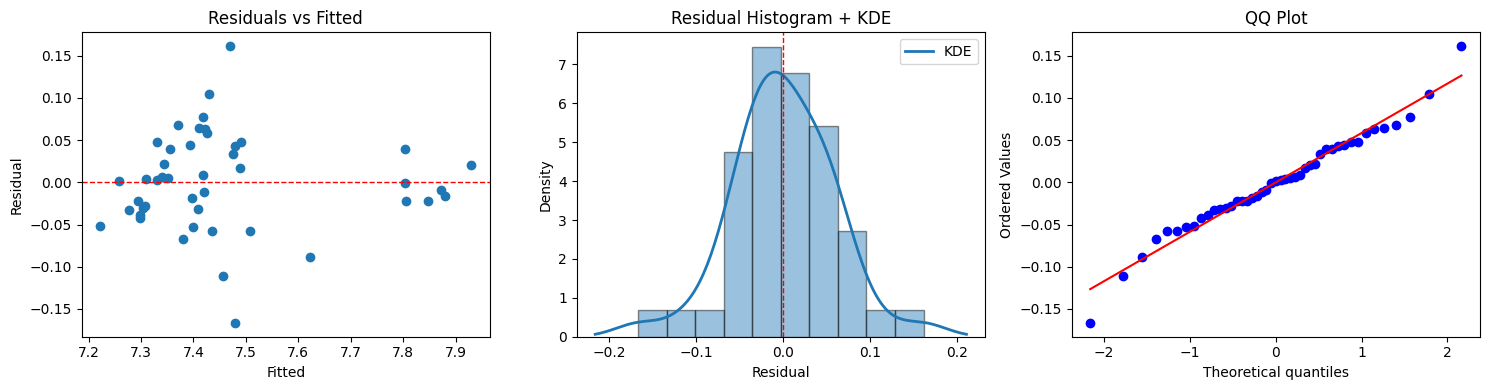

In [7]:
main_features = time_features

main_result = ols(
    model_rows,
    "ln_price",
    main_features,
    exclude_case_ids=excluded_case_ids,
)

print("\n主模型：HC3 robust standard errors")
print_summary(main_result, robust=True)

print("\n主模型 VIF")
print_vif_table(variance_inflation_factors(main_result["rows"], main_features))

print("\n主模型殘差診斷")
print_residual_diagnostics(
    main_result["rows"],
    main_result,
    main_features,
    id_cols=["Case_ID", "成交年分數_相對起點", "成交總價_含車位_萬元", "建坪_含車位", "樓層", "屋齡"],
)

plot_residual_diagnostics(main_result);

## 6. 標的物估價與模型比較

PDF 標的物為中美路 111 號、約 67.44 坪、中高樓層華廈。下方示範先假設 5 樓、9.3 年屋齡、有車位；實際樓層、屋齡、車位可以改 `target`。

主模型、屋齡中心化模型與時間趨勢模型會一起列出，作為估價敏感度比較。

In [12]:
# ===== 標的物條件設定 =====

target = {
    # 標的物成交時間：2026 年 5 月
    "成交年分數": 2026 + (5 - 1) / 12,

    # 標的物條件
    "建坪_含車位": 67.44,
    "樓層": 5,
    "屋齡": 9.3,
    "有車位虛擬變數": 1,
    "中高樓層虛擬變數": 1,
}

# 時間趨勢模型使用
target["成交年分數_相對起點"] = target["成交年分數"] - first_transaction_time

# 屋齡中心化模型若後面還要敏感度比較才需要
target["屋齡_center"] = target["屋齡"] - age_mean


# ===== 最終主模型估價 =====

ln_pred, price_pred = predict_price(main_result, main_features, target)

# RMSE(log)
resid = main_result["model"].resid
rmse_log = np.sqrt(np.mean(resid ** 2))

# 以 ±1 個 RMSE(log) 建立約略估價區間
lower_price = price_pred * np.exp(-rmse_log)
upper_price = price_pred * np.exp(rmse_log)

print("最終主模型：時間趨勢模型")
print(f"估計 ln(總價): {ln_pred:.4f}")
print(f"估計總價: {price_pred:,.0f} 萬元")
print(f"估計單價: {price_pred / target['建坪_含車位']:,.2f} 萬元/坪")
print(f"約略估價區間: {lower_price:,.0f} ~ {upper_price:,.0f} 萬元")
print(
    f"區間單價: "
    f"{lower_price / target['建坪_含車位']:,.2f} ~ "
    f"{upper_price / target['建坪_含車位']:,.2f} 萬元/坪"
)

最終主模型：時間趨勢模型
估計 ln(總價): 7.4960
估計總價: 1,801 萬元
估計單價: 26.70 萬元/坪
約略估價區間: 1,701 ~ 1,907 萬元
區間單價: 25.22 ~ 28.27 萬元/坪
